# Procesamiento Digital de Imágenes - TP05: Dominio Frecuencial

**Objetivos de la guía:**

* Fijar los conceptos relacionados a la Transformada de Fourier bidimensional (TDF 2D) mediante su visualización.

* Comprender el proceso de filtrado en el dominio de la frecuencia.

* Aplicar filtros de acentuado en frecuencia y comprobar la ventaja computacional de la rutina FFT.




In [1]:
# Configuración Inicial
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imutils # Para la rotación de imágenes solicitada en el Ejercicio 1 y 4
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets
import helpers

def mostrar_img_y_espectro(img, dft_shift, titulo="Imagen"):
    """Función auxiliar para mostrar una imagen y su espectro de magnitud centrado"""
    # Calcular magnitud: 20 * log(magnitud) para poder visualizarla correctamente
    # dft_shift tiene 2 canales: real e imaginario
    magnitud = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].imshow(img, cmap='gray')
    axs[0].set_title(titulo)
    axs[0].axis('off')

    axs[1].imshow(magnitud, cmap='gray')
    axs[1].set_title('Espectro de Magnitud (TDF)')
    axs[1].axis('off')
    plt.show()

print("Entorno configurado. ¡Sube las imágenes de prueba (puente.jpg, ferrari-c.png, parrafo0.jpg)!")

Entorno configurado. ¡Sube las imágenes de prueba (puente.jpg, ferrari-c.png, parrafo0.jpg)!


## Ejercicio 1: Conceptos básicos de la TDF 2D

* Construiremos imágenes binarias simples para entender cómo se distribuye la energı́a en el dominio frecuencial.

* Verificaremos cómo la rotación en el dominio espacial afecta al dominio frecuencial



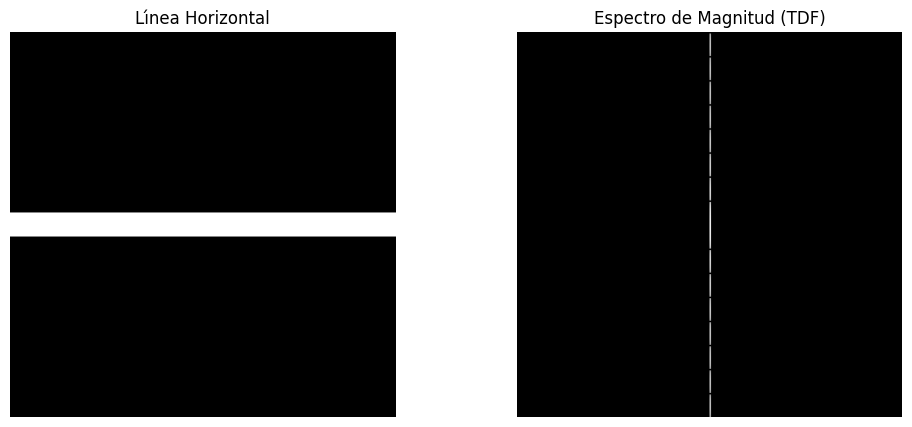

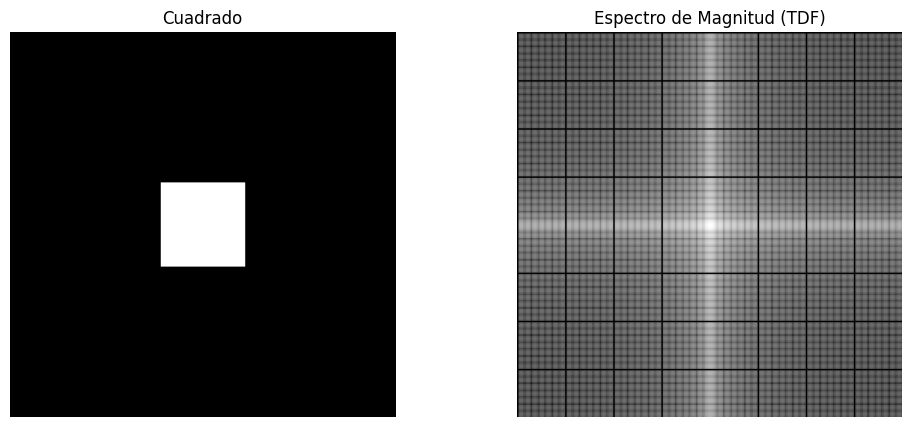

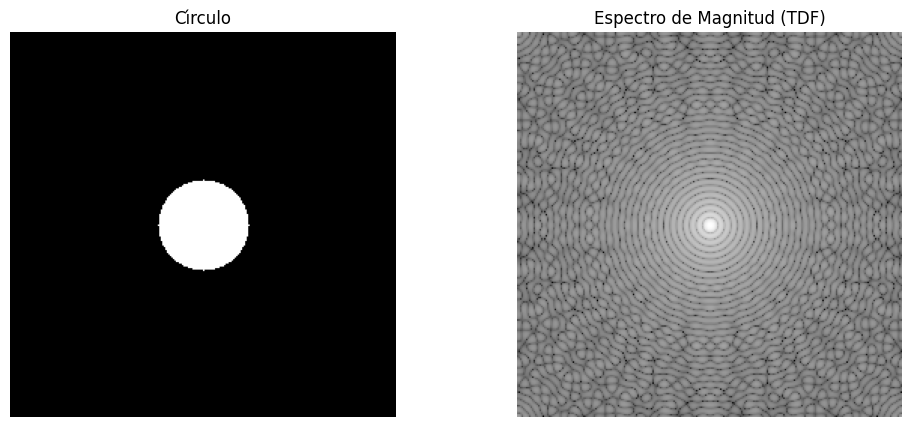

In [2]:
# Figuras Básicas y su TDF

def analizar_tdf_basica():
    # 1. Construir imágenes binarias de 256x256
    img_linea_h = np.zeros((256, 256), dtype=np.float32)
    img_linea_h[120:136, :] = 255 # Lı́nea horizontal gruesa

    img_cuadrado = np.zeros((256, 256), dtype=np.float32)
    img_cuadrado[100:156, 100:156] = 255 # Cuadrado centrado

    img_circulo = np.zeros((256, 256), dtype=np.float32)
    cv2.circle(img_circulo, (128, 128), 30, 255, -1) # Cı́rculo centrado

    imagenes = [("Lı́nea Horizontal", img_linea_h),
                ("Cuadrado", img_cuadrado),
                ("Cı́rculo", img_circulo)]

    for nombre, img in imagenes:
        # TODO: Calcular la TDF usando cv2.dft (recuerda usar el flag cv2.DFT_COMPLEX_OUTPUT)
        dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)

        # TODO: Centrar la TDF usando np.fft.fftshift
        dft_shift = np.fft.fftshift(dft)

        mostrar_img_y_espectro(img, dft_shift, titulo=nombre)

analizar_tdf_basica()

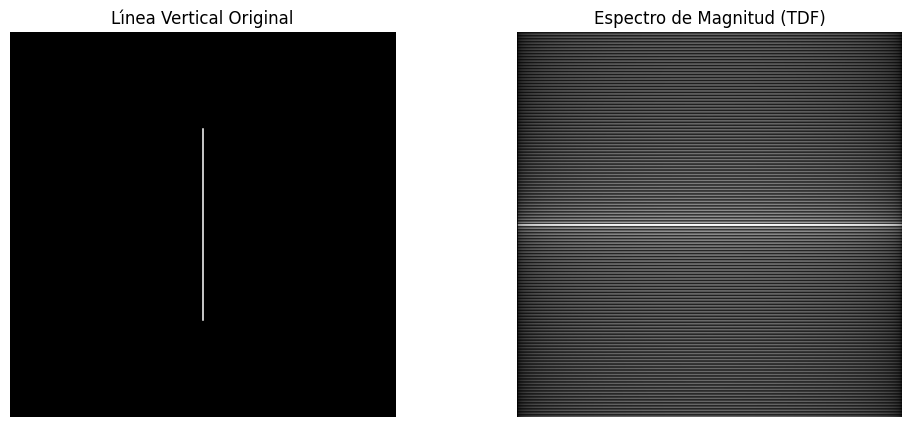

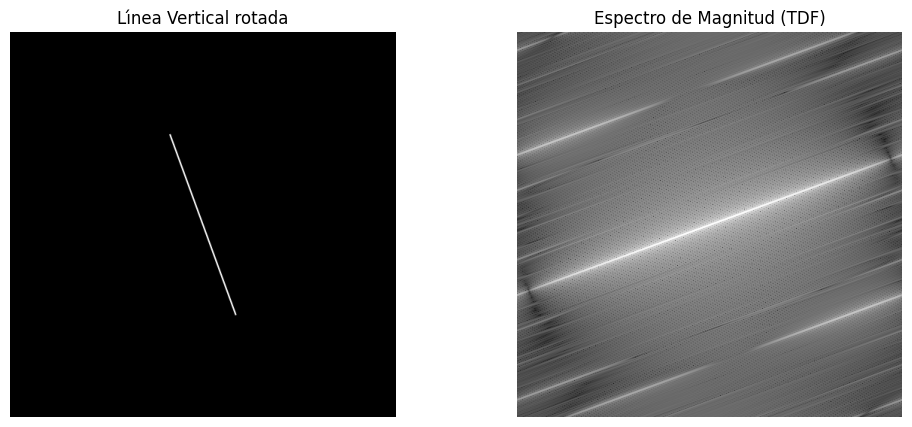

In [3]:
# Rotación y TDF
def analizar_rotacion():
    # Construir imagen de 512x512 con lı́nea vertical de 1px
    img = np.zeros((512, 512), dtype=np.float32)
    img[128:384, 255:257] = 255

    # TODO: Rotar la imagen 20 grados usando imutils.rotate
    img_rotada = imutils.rotate(img, angle=20)

    # TODO: Extraer una sección central de 256x256 de ambas imágenes
    sec_original = img[128:384, 128:384]
    sec_rotada = img_rotada[128:384, 128:384]

    # Calcular y mostrar TDF de la sección original
    dft_orig = cv2.dft(img, flags=cv2.DFT_COMPLEX_OUTPUT)
    mostrar_img_y_espectro(img, np.fft.fftshift(dft_orig), "Lı́nea Vertical Original")

    # Calcular y mostrar TDF de la sección rotada
    dft_rot = cv2.dft(img_rotada, flags=cv2.DFT_COMPLEX_OUTPUT)
    mostrar_img_y_espectro(img_rotada, np.fft.fftshift(dft_rot), "Lı́nea Vertical rotada")

analizar_rotacion()


**Reflexiona sobre lo que observas:**

* Al visualizar el espectro de la línea horizontal y la línea vertical, ¿qué relación notas entre la orientación geométrica del objeto en el dominio espacial y la distribución de la energía en el dominio de las frecuencias?

En el experimento de la rotación:
* compara la TDF de la imagen original con la TDF de la imagen rotada.
* ¿Qué le ocurre exactamente a la magnitud de la TDF cuando el objeto espacial gira?
* ¿Qué propiedad fundamental de la Transformada de Fourier se está comprobando aquí?

Las lineas horizontales tienen un espectro de frecuencias vertical pues es en esa dirección en donde se producen cambios bruscos. Si recorremos la imagen de forma horizontal, no habra cambios (frecuencia 0). La misma lógica se puede aplica a las lineas verticales.

En la rotación, lo que sucede es que la magnitud sufre una rotación exactamente igual y en el mismo sentido, esto coincide con la **propiedad de rotación de la transformada**.

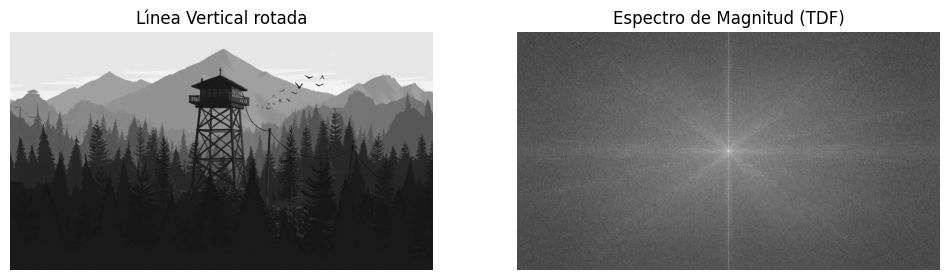

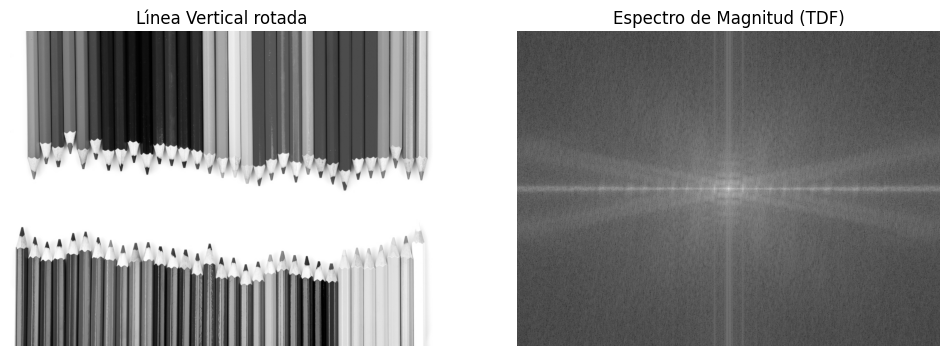

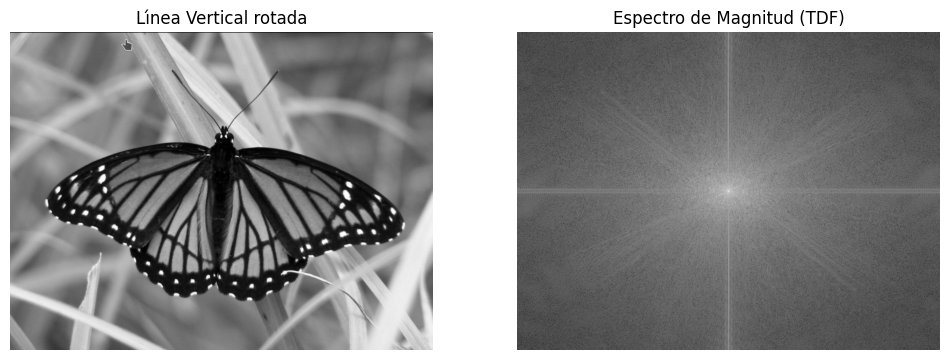

In [4]:
firewatch_img = cv2.imread('imagenes/firewatch.png', cv2.IMREAD_GRAYSCALE)
lapices_img = cv2.imread('imagenes/lapices02.jpg', cv2.IMREAD_GRAYSCALE)
mariposa_img = cv2.imread('imagenes/mariposa02.png', cv2.IMREAD_GRAYSCALE)

firewatch_rot = cv2.dft(np.float32(firewatch_img), flags=cv2.DFT_COMPLEX_OUTPUT)
mostrar_img_y_espectro(firewatch_img, np.fft.fftshift(firewatch_rot), "Lı́nea Vertical rotada")
lapices_rot = cv2.dft(np.float32(lapices_img), flags=cv2.DFT_COMPLEX_OUTPUT)
mostrar_img_y_espectro(lapices_img, np.fft.fftshift(lapices_rot), "Lı́nea Vertical rotada")
mariposa_rot = cv2.dft(np.float32(mariposa_img), flags=cv2.DFT_COMPLEX_OUTPUT)
mostrar_img_y_espectro(mariposa_img, np.fft.fftshift(mariposa_rot), "Lı́nea Vertical rotada")

## Ejercicio 2: Importancia de la Fase

Genere una imagen reconstruida solo con la magnitud considerando fase cero y otra usando solo fase y considerando magnitud unitaria

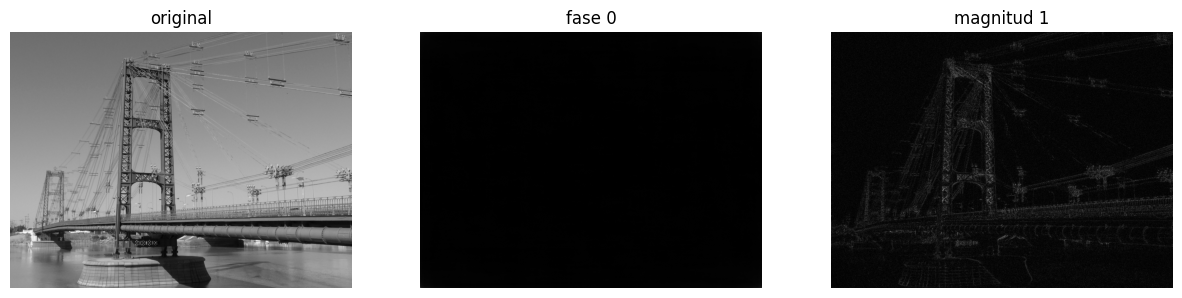

In [5]:
puente = cv2.imread('imagenes/puente.jpg', cv2.IMREAD_GRAYSCALE)

dft = np.fft.fft2(np.float32(puente))

mag, fase = np.abs(dft), np.angle(dft)

# sin fase
complejo_A = mag
img_A = np.abs(np.fft.ifft2(complejo_A))

# magnitud unitaria
complejo_B = 1 * np.exp(1j * fase)
img_B = np.abs(np.fft.ifft2(complejo_B))

fig, ax = plt.subplots(1, 3, figsize=(10, 10))
fig.set_figwidth(15)
ax[0].imshow(puente, cmap='gray'); ax[0].set_title("original")
ax[1].imshow(img_A, cmap='gray'); ax[1].set_title("fase 0")
ax[2].imshow(img_B, cmap='gray'); ax[2].set_title("magnitud 1")
for axs in ax.flat: axs.axis('off')
plt.show()

Reproduciremos el experimento de Oppenheim intercambiando la magnitud y la fase de dos imágenes distintas (***puente.jpg*** y ***ferrari-c.png***).

---

Recordemos que un número complejo se forma como:

$$\text{Magnitud} \cdot e^{j \cdot \text{Fase}}$$

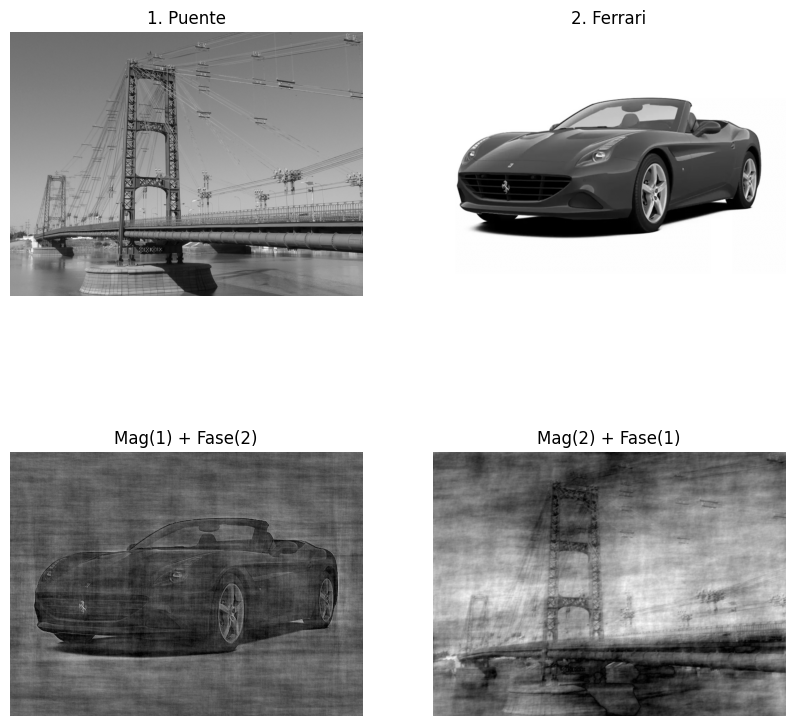

In [6]:
# Experimento de Oppenheim

def experimento_oppenheim(img1_path, img2_path):
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None: return "Cargar puente.jpg y ferrari-c.png"

    # Redimensionar para que tengan el mismo tamaño
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Calcular TDF de ambas imágenes (en numpy es más fácil manipular fase/magnitud)
    f1 = np.fft.fft2(img1)
    f2 = np.fft.fft2(img2)

    # Extraer Magnitud y Fase
    mag1, fase1 = np.abs(f1), np.angle(f1)
    mag2, fase2 = np.abs(f2), np.angle(f2)

    # Reconstruir Imagen A (Magnitud de IMG1 + Fase de IMG2)
    complejo_A = mag1 * np.exp(1j * fase2)
    img_A = np.abs(np.fft.ifft2(complejo_A))

    # Reconstruir Imagen B (Magnitud de IMG2 + Fase de IMG1)
    complejo_B = mag2 * np.exp(1j * fase1)
    img_B = np.abs(np.fft.ifft2(complejo_B))

    # Visualización
    fig, ax = plt.subplots(2, 2, figsize=(10, 10))
    ax[0][0].imshow(img1, cmap='gray'); ax[0][0].set_title("1. Puente")
    ax[0][1].imshow(img2, cmap='gray'); ax[0][1].set_title("2. Ferrari")
    ax[1][0].imshow(img_A, cmap='gray'); ax[1][0].set_title("Mag(1) + Fase(2)")
    ax[1][1].imshow(img_B, cmap='gray'); ax[1][1].set_title("Mag(2) + Fase(1)")
    for axs in ax.flat: axs.axis('off')
    plt.show()

# Ejecutar
experimento_oppenheim('imagenes/puente.jpg', 'imagenes/ferrari-c.png')


Se puede observar que la fase guarda la estructura geométrica de la imagen, por eso lo que podemos distinguir en cada mezcla es siempre la imagen a la cual corresponde la fase mezclada. En el caso en que anulemos la magnitud (magnitud unitaria en todo el plano), aún podeemos ver algunos de los detalles gracias a la fase, pero viceversa (magnitud real y fase cero).

## Ejercicio 3: Filtros Pasa-Bajos y Pasa-Altos

Diseñaremos filtros ideales y evaluaremos el fenómeno de Gibbs, y luego aplicaremos filtros gaussianos en el dominio frecuencial.

Usaremos un deslizador interactivo para variar la frecuencia de corte.


* **Implemente** las versiones Butterworth y Gaussianas indicadas en la guı́a.

In [7]:
#  Filtro Pasa-Bajos Ideal Interactivo
img = cv2.imread('imagenes/puente.jpg', cv2.IMREAD_GRAYSCALE)
def actualizar(freq, orden, sigma):
    filas, cols = img.shape
    crow, ccol = filas // 2, cols // 2

    # Crear máscara (Filtro Ideal Pasa-Bajos): Cı́rculo de 1s, resto 0s
    mask = np.zeros((filas, cols, 2), np.uint8)
    cv2.circle(mask, (ccol, crow), freq, (1, 1), -1)

    img_fideal = helpers.apply_pb_ideal(img, freq)
    img_fbutter = helpers.apply_pb_butterworth(img, freq, orden)
    img_fgauss = helpers.apply_pb_gaussiano(img, sigma)

    fig, ax = plt.subplots(1, 4, figsize=(15, 10))
    ax[0].imshow(img, cmap='gray'); ax[0].set_title(f"Puente")
    ax[1].imshow(img_fideal, cmap='gray'); ax[1].set_title("Imagen Filtrada (Ideal)")
    ax[2].imshow(img_fbutter, cmap='gray'); ax[2].set_title("Imagen Filtrada (Butter)")
    ax[3].imshow(img_fgauss, cmap='gray'); ax[3].set_title("Imagen Filtrada (Gauss)")

    for axi in ax: axi.axis('off')
    plt.show();

# Interfaz interactiva para modificar la frecuencia de corte
interact(
    actualizar,
    freq=IntSlider(min=10, max=150, step=1, value=40),
    orden=IntSlider(min=1, max=10, step=1, value=2),
    sigma=IntSlider(min=1, max=75, step=1, value=25)
);

interactive(children=(IntSlider(value=40, description='freq', max=150, min=10), IntSlider(value=2, description…

El filtro ideal produce el fenomeno de Gibbs ya que la forma de este en el dominio espacial es la de una funcion sinc en dos dimensiones (que tiene forma de onda). En el caso de los filtros Gaussianos y Butterworth, este fenomeno se elimina en gran medida gracias a que no tienen un corte abrupto, sino suave.

### Repita para pasa-altos

In [8]:
#  Filtro Pasa-Bajos Ideal Interactivo
img = cv2.imread('imagenes/puente.jpg', cv2.IMREAD_GRAYSCALE)
def actualizar(freq, orden, sigma):
    filas, cols = img.shape
    crow, ccol = filas // 2, cols // 2

    # Crear máscara (Filtro Ideal Pasa-Altos): Cı́rculo de 1s, resto 0s
    mask = np.zeros((filas, cols, 2), np.uint8)
    cv2.circle(mask, (ccol, crow), freq, (1, 1), -1)

    img_fideal = helpers.apply_pa_ideal(img, freq)
    img_fbutter = helpers.apply_pa_butterworth(img, freq, orden)
    img_fgauss = helpers.apply_pa_gaussiano(img, sigma)

    fig, ax = plt.subplots(1, 4, figsize=(15, 10))
    ax[0].imshow(img, cmap='gray'); ax[0].set_title(f"Puente")
    ax[1].imshow(img_fideal, cmap='gray'); ax[1].set_title("Imagen Filtrada (Ideal)")
    ax[2].imshow(img_fbutter, cmap='gray'); ax[2].set_title("Imagen Filtrada (Butter)")
    ax[3].imshow(img_fgauss, cmap='gray'); ax[3].set_title("Imagen Filtrada (Gauss)")

    for axi in ax: axi.axis('off')
    plt.show();

# Interfaz interactiva para modificar la frecuencia de corte
interact(
    actualizar,
    freq=IntSlider(min=10, max=150, step=1, value=40),
    orden=IntSlider(min=1, max=10, step=1, value=2),
    sigma=IntSlider(min=1, max=75, step=1, value=25)
);

interactive(children=(IntSlider(value=40, description='freq', max=150, min=10), IntSlider(value=2, description…

## Ejercicio 4: Filtrado Homomórfico

El filtrado homomórfico permite corregir la iluminación no uniforme modificando el contraste y acentuando detalles. La secuencia matemática es:

$$f(x,y) \xrightarrow{\ln} \mathcal{F} \xrightarrow{H(u,v)} \mathcal{F}^{-1} \xrightarrow{\exp} g(x,y)$$

In [9]:
# Filtrado Homomórfico

def filtrado_homomorfico(img_path, gH=1.5, gL=0.5, D0=30, c=1.0):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return f"Carga la imagen '{img_path}'" [6]

    img_homomorfica = helpers.apply_homomorfica(img, gH, gL, D0, c)

    # --- Comparación con Ecualización Global ---
    img_ecualizada = cv2.equalizeHist(img)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img, cmap='gray'); ax[0].set_title("Original")
    ax[1].imshow(img_ecualizada, cmap='gray'); ax[1].set_title("Ecualización Pura")
    ax[2].imshow(img_homomorfica, cmap='gray'); ax[2].set_title(f"Homomórfico (gH={gH}, gL={gL})")
    for axi in ax: axi.axis('off')
    plt.show();

# Interfaz interactiva.
# TODO: Probar con 'casilla.tif' y 'reunion.tif' variando parámetros.
interact(filtrado_homomorfico,
         img_path=['imagenes/casilla.tif', 'imagenes/reunion.tif'],
         gH=FloatSlider(min=0.1, max=3.0, step=0.1, value=1.5),
         gL=FloatSlider(min=0.1, max=1.0, step=0.1, value=0.5),
         D0=IntSlider(min=1, max=150, step=1, value=30),
         c=FloatSlider(min=0.5, max=20.0, step=0.5, value=1.0));


interactive(children=(Dropdown(description='img_path', options=('imagenes/casilla.tif', 'imagenes/reunion.tif'…

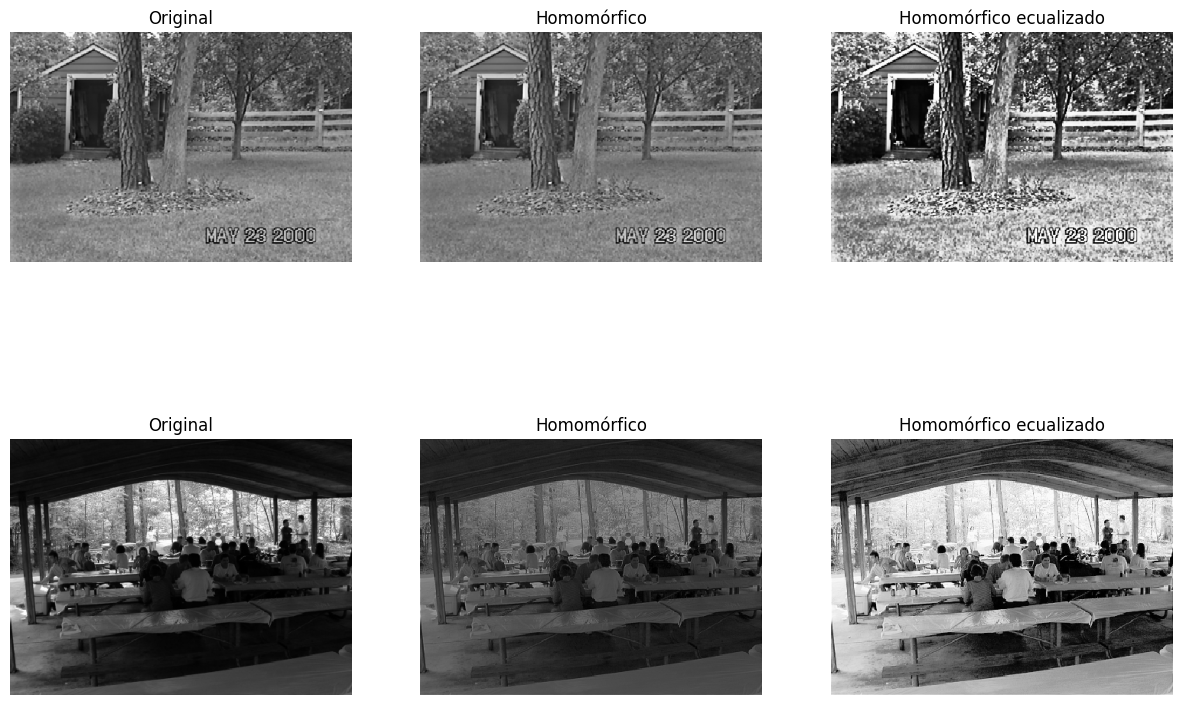

In [10]:
casilla = cv2.imread('imagenes/casilla.tif', cv2.IMREAD_GRAYSCALE)
reunion = cv2.imread('imagenes/reunion.tif', cv2.IMREAD_GRAYSCALE)

gH_casilla, gL_casilla, D0_casilla, c_casilla = 0.9, 0.60, 39, 20
gH_reunion, gL_reunion, D0_reunion, c_reunion = 1.0, 0.4, 120, 0.5

casilla_homomorfica = helpers.apply_homomorfica(casilla, gH_casilla, gL_casilla, D0_casilla, c_casilla)
reunion_homomorfica = helpers.apply_homomorfica(reunion, gH_reunion, gL_reunion, D0_reunion, c_reunion)

casilla_homomorfica_eq = cv2.equalizeHist(casilla_homomorfica)
reunion_homomorfica_eq = cv2.equalizeHist(reunion_homomorfica)

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0][0].imshow(casilla, cmap='gray'); ax[0][0].set_title("Original"); ax[0][0].axis('off')
ax[0][1].imshow(casilla_homomorfica, cmap='gray'); ax[0][1].set_title("Homomórfico"); ax[0][1].axis('off')
ax[0][2].imshow(casilla_homomorfica_eq, cmap='gray'); ax[0][2].set_title("Homomórfico ecualizado"); ax[0][2].axis('off')
ax[1][0].imshow(reunion, cmap='gray'); ax[1][0].set_title("Original"); ax[1][0].axis('off')
ax[1][1].imshow(reunion_homomorfica, cmap='gray'); ax[1][1].set_title("Homomórfico"); ax[1][1].axis('off')
ax[1][2].imshow(reunion_homomorfica_eq, cmap='gray'); ax[1][2].set_title("Homomórfico ecualizado"); ax[1][2].axis('off')
plt.show();

La idea del filtro homomorfico es separar la imagen las componentes de iluminación y reflectancia. Ya que en el modelo de imagen estas se multiplican, aplicamos el logarítmo para transformala en una suma, y luego cuando pasamos al dominio frecuencial tenemos que la componente de iluminación toma las frecuencias bajas, mientras que la reflectancia toma las frecuencias altas. Con los parámetros `gL`, `gH` y `D0` podemos ajustar cuánto atenuamos o amplificamos las frecuencias altas o bajas. Al atenuar las frecuencias bajas oscurecemos las zonas sobreiluminadas y al amplificar las fecuencias altas realzamos los detalles que se encuentran en sombras.

La combinacion de ecualizacion luego de filtrado, en el caso de la imagen de la casilla, oscurece los detalles que habia revelado el filtro homomorfico, mientras que en la segunda imagen acentuo algunos detalles en sombras, pero sobreexpuso los elementos que ya se encontraban iluminados.

## Ejercicio 5: Filtros de acentuado en el dominio frecuencial

Compararemos un filtro de Alta Potencia ($H_{AP}$) y un filtro de Énfasis de Alta Frecuencia ($H_{EAF}$) aplicados a la imagen **camaleon.tif**.


---

* Compare la imagen de alta potencia con la que se obtiene al aplicar  el filtro equivalente en el dominio espacial.


In [11]:
# Filtros de Acentuado

img = cv2.imread('imagenes/camaleon.tif', cv2.IMREAD_GRAYSCALE)
def acentuado_frecuencial(A=1.5, a=0.5, b=2.0):
    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    # Filtro pasa altos gaussiano
    H_PA = helpers.mask_pa_butterworth(img, 25, 8)

    # 1. Filtro de Alta Potencia: H_AP = (A - 1) + H_PA
    H_AP = (A - 1) + H_PA

    # 2. Filtro de alto enfasis de alta frecuencia
    H_EAF = a + b * H_PA

    # Aplicar filtros
    dft_AP = dft_shift * H_AP[:, :, np.newaxis]
    dft_EAF = dft_shift * H_EAF[:, :, np.newaxis]

    # Función auxiliar para IDFT
    def inversa(espectro):
        f_ishift = np.fft.ifftshift(espectro)
        img_back = cv2.idft(f_ishift, flags=cv2.DFT_SCALE)
        mag = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])
        return cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    img_AP = inversa(dft_AP)
    img_EAF = inversa(dft_EAF)

    fig, ax = plt.subplots(1, 3, figsize=(15, 10))
    ax[0].imshow(img, cmap='gray'); ax[0].set_title("Original")
    ax[1].imshow(img_AP, cmap='gray'); ax[1].set_title(f"Alta Potencia (A={A})")
    ax[2].imshow(img_EAF, cmap='gray'); ax[2].set_title(f"Énfasis AF (a={a}, b={b})")
    for axi in ax: axi.axis('off')
    plt.show();

interact(acentuado_frecuencial,
         A=FloatSlider(min=1.0, max=3.0, step=0.1, value=1.5),
         a=FloatSlider(min=0.1, max=5.0, step=0.1, value=0.5),
         b=FloatSlider(min=1.0, max=4.0, step=0.1, value=2.0));

interactive(children=(FloatSlider(value=1.5, description='A', max=3.0, min=1.0), FloatSlider(value=0.5, descri…

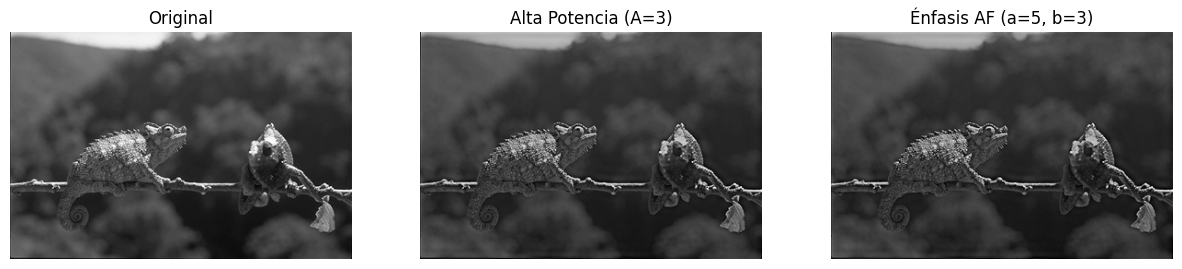

In [12]:
A = 3
a = 5
b = 3

dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

# Filtro pasa altos gaussiano
H_PA = helpers.mask_pa_butterworth(img, 25, 8)

# 1. Filtro de Alta Potencia: H_AP = (A - 1) + H_PA
H_AP = (A - 1) + H_PA

# 2. Filtro de alto enfasis de alta frecuencia
H_EAF = a + b * H_PA

# Aplicar filtros
dft_AP = dft_shift * H_AP[:, :, np.newaxis]
dft_EAF = dft_shift * H_EAF[:, :, np.newaxis]

# Función auxiliar para IDFT
def inversa(espectro):
    f_ishift = np.fft.ifftshift(espectro)
    img_back = cv2.idft(f_ishift, flags=cv2.DFT_SCALE)
    mag = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])
    return cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

img_AP = inversa(dft_AP)
img_EAF = inversa(dft_EAF)

fig, ax = plt.subplots(1, 3, figsize=(15, 10))
ax[0].imshow(img, cmap='gray'); ax[0].set_title("Original")
ax[1].imshow(img_AP, cmap='gray'); ax[1].set_title(f"Alta Potencia (A={A})")
ax[2].imshow(img_EAF, cmap='gray'); ax[2].set_title(f"Énfasis AF (a={a}, b={b})")
for axi in ax: axi.axis('off')
plt.show();

Con el filtro de enfasiz de alta frecuencia logramos separar el control entre el resaltado de bordes (b) y el brillo general de la imagen (a). El filtro highboost es un caso particular de este donde a=A-1 y b=1.

Al variar `b` podemos hacer que se noten mejor los detalles en la textura del camaleón.

### Comparar highboost en frecuencias y en espacio

In [13]:
# Filtros de Acentuado
img = cv2.imread('imagenes/camaleon.tif', cv2.IMREAD_GRAYSCALE)
def actualizar(A=1.5, ksize=3):

    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    # Alta potencia en frecuencia con filtro gaussiano
    H_PA = helpers.mask_pa_gaussiano(img, 1)
    H_AP = (A - 1) + H_PA
    dft_AP = dft_shift * H_AP[:, :, np.newaxis]
    f_ishift = np.fft.ifftshift(dft_AP)
    img_back = cv2.idft(f_ishift, flags=cv2.DFT_SCALE)
    mag = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])
    img_AP = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # Alta potencia espacial
    esp_AP = helpers.altaPotencia(img, kernelSize=(ksize, ksize), A=A)
    esp_AP = cv2.normalize(esp_AP, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    fig, ax = plt.subplots(1, 3, figsize=(15, 10))
    ax[0].imshow(img, cmap='gray'); ax[0].set_title("Original")
    ax[1].imshow(img_AP, cmap='gray'); ax[1].set_title("Alta Potencia en frecuencia")
    ax[2].imshow(esp_AP, cmap='gray'); ax[2].set_title("Alta Potencia espacial")
    for axi in ax: axi.axis('off')
    plt.show();

interact(actualizar,
         A=FloatSlider(min=1.0, max=3.0, step=0.1, value=1.5),
         ksize=IntSlider(min=1, max=30, step=2, value=3)
);

interactive(children=(FloatSlider(value=1.5, description='A', max=3.0, min=1.0), IntSlider(value=3, descriptio…

En el caso del filtrado de alta potencia en el dominio espacial los resultados variarán dependiendo del tamaño del kernel, pero aún así veremos una "niebla" en la imagen, que no tiene relación con nuestro objetivo, que debería ser solo el realzar los bordes.

## Ejercicio 6.1: Rendimiento de FFT y agregado de ceros (Zero-Padding)

La transformada rápida (FFT) es mucho más eficiente cuando las dimensiones de la imagen son potencias de 2.

---

* OpenCV incluye la función **cv2.getOptimalDFTSize()** para determinar este tamaño.
* Agregaremos un borde de relleno (zero-padding) y mediremos el rendimiento.

---

**Reflexión**:

¿Qué efecto numérico (objetivo) y visual (subjetivo) produce el agregado de ceros?

Tamaño Original: 307x442
Tamaño Óptimo (FFT): 320x450
------------------------------
Tiempo Original (307x442): 0.0128 seg
Tiempo Óptimo   (320x450): 0.0080 seg
Tiempo Peor     (319x449): 0.0155 seg


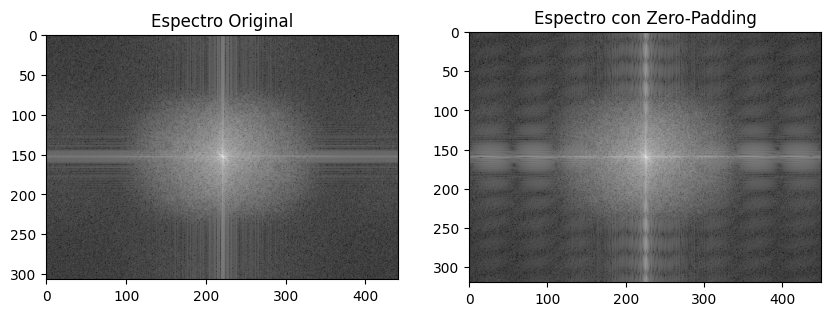

In [14]:
# FFT vs DFT
import timeit

def evaluar_rendimiento_fft(img_path='imagenes/puente.jpg'):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return "Carga una imagen."

    filas, cols = img.shape
    print(f"Tamaño Original: {filas}x{cols}")

    # 1. Obtener tamaño óptimo para FFT
    Nopt = cv2.getOptimalDFTSize(filas)
    Mopt = cv2.getOptimalDFTSize(cols)
    print(f"Tamaño Óptimo (FFT): {Nopt}x{Mopt}")

    # 2. Generar imagen óptima (Padding)
    # TODO: Usa cv2.copyMakeBorder agregando ceros a la derecha y abajo
    img_opt = cv2.copyMakeBorder(img, 0, Nopt - filas, 0, Mopt - cols, cv2.BORDER_CONSTANT, value=0)

    # 3. Generar imagen (Óptima - 1)
    N_peor = Nopt - 1
    M_peor = Mopt - 1
    img_peor = cv2.copyMakeBorder(img, 0, max(0, N_peor - filas), 0, max(0, M_peor - cols), cv2.BORDER_CONSTANT, value=0)
    # Forzamos el recorte si era más grande
    img_peor = img_peor[:N_peor, :M_peor]

    # 4. Evaluar tiempos de ejecución
    def test_dft(imagen):
        cv2.dft(np.float32(imagen), flags=cv2.DFT_COMPLEX_OUTPUT)

    t_orig = timeit.timeit(lambda: test_dft(img), number=10)
    t_opt = timeit.timeit(lambda: test_dft(img_opt), number=10)
    t_peor = timeit.timeit(lambda: test_dft(img_peor), number=10)

    print("-" * 30)
    print(f"Tiempo Original ({filas}x{cols}): {t_orig:.4f} seg")
    print(f"Tiempo Óptimo   ({Nopt}x{Mopt}): {t_opt:.4f} seg")
    print(f"Tiempo Peor     ({N_peor}x{M_peor}): {t_peor:.4f} seg")

    # 5. Visualizar el efecto subjetivo de agregar ceros en el espectro
    dft_orig = np.fft.fftshift(cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT))
    dft_opt = np.fft.fftshift(cv2.dft(np.float32(img_opt), flags=cv2.DFT_COMPLEX_OUTPUT))

    mag_orig = 20 * np.log1p(cv2.magnitude(dft_orig[:,:,0], dft_orig[:,:,1]))
    mag_opt = 20 * np.log1p(cv2.magnitude(dft_opt[:,:,0], dft_opt[:,:,1]))

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(mag_orig, cmap='gray'); ax[0].set_title("Espectro Original")
    ax[1].imshow(mag_opt, cmap='gray'); ax[1].set_title("Espectro con Zero-Padding")
    plt.show()


evaluar_rendimiento_fft('imagenes/camino.tif')

El **efecto objetivo** que se puede ver es que el tiempo de procesamiento es mucho menor cuando se tiene un tamaño óptimo (potencia de 2). Esto se debe a que el método de FFT puede aplicar la división de la imagen en mitades de forma recursiva (divide and conquer). Los tamaños "peores" obligan al algoritmo a utilizar otros métodos con mayor costo computacional.

El **efecto subjetivo** (a la vista) que se observa en la representación del espectro se debe a que el agregar ceros en el dominio espacial equivale a aumentar la tasa de muestreo en el dominio frecuencial. Esto tiene como resultado una interpolación de la forma de onda ya existente.

## Ejercicio 6.2: Trabajo de Aplicación - Preprocesamiento OCR

El objetivo es **identificar si un texto escaneado está rotado** y, de ser así, corregir su orientación automáticamente analizando el dominio de la frecuencia.

---
**Notas:**

* En el espectro de magnitud del texto, verás una lı́nea brillante ortogonal a las lı́neas de texto. Aquí puedes usar tu ingenio para detectar el ángulo de esta línea, puedes comenzar usando un umbral sobre la magnitud ...

* Puedes usar **imutils.rotate** o **cv2.warpAffine** para enderezar el texto original.



In [67]:
#  Detección y Corrección de Rotación OCR
def corregir_rotacion_ocr(img_path, thresh, lineasThresh):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return f"Error al cargar {img_path}"

    # PASO 1: Calcular la TDF de la imagen del texto
    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitud = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)
    magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # PASO 2: Encontrar el ángulo de rotación
    # borrar la componente del centro del espectro
    espectro = magnitud.copy()
    c_y, c_x = espectro.shape[0] // 2, espectro.shape[1] // 2   # centro
    espectro[c_y-10:c_y+10, c_x-10:c_x+10] = 0  # cuadro negro

    # umbralizar para aislar la línea brillante ortogonal
    _, espectro_thresh = cv2.threshold(espectro, thresh, 255, cv2.THRESH_BINARY)
    lineas = cv2.HoughLines(espectro_thresh, 1, np.pi/180, lineasThresh)

    # tomar linea con mas votos
    rho, theta = lineas[0][0]
    angulo = np.degrees(theta)

    # PASO 3: Corregir la imagen
    img_corregida = imutils.rotate(img, angle=angulo)

    fig, ax = plt.subplots(2, 3, figsize=(15, 5))
    ax[0][0].imshow(img, cmap='gray'); ax[0][0].set_title("Texto Original"); ax[0][0].axis('off')
    ax[0][1].imshow(magnitud, cmap='gray'); ax[0][1].set_title("Espectro"); ax[0][1].axis('off')
    ax[0][2].imshow(espectro, cmap='gray'); ax[0][2].set_title("Espectro sin componente central"); ax[0][2].axis('off')
    ax[1][0].imshow(espectro_thresh, cmap='gray'); ax[1][0].set_title("Espectro umbralizado"); ax[1][0].axis('off')
    ax[1][1].imshow(img_corregida, cmap='gray'); ax[1][1].set_title(f"Corregida (Ang: {angulo})"); ax[1][1].axis('off')

    # espectro rotado
    dft = cv2.dft(np.float32(img_corregida), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitud = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)
    magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    ax[1][2].imshow(magnitud, cmap='gray'); ax[1][2].set_title(f"Espectro corregido"); ax[1][2].axis('off')

    plt.show();

interact(corregir_rotacion_ocr,
         img_path='imagenes/parrafo1.jpg',
         thresh=IntSlider(min=1, max=170, step=1, value=160),
         lineasThresh=IntSlider(min=1, max=100, step=1, value=80)
);

interactive(children=(Text(value='imagenes/parrafo1.jpg', description='img_path'), IntSlider(value=160, descri…

A partir de prueba y error se encontraron los mejores parámetros para umbralizacion del espectro y el algoritmo de hough

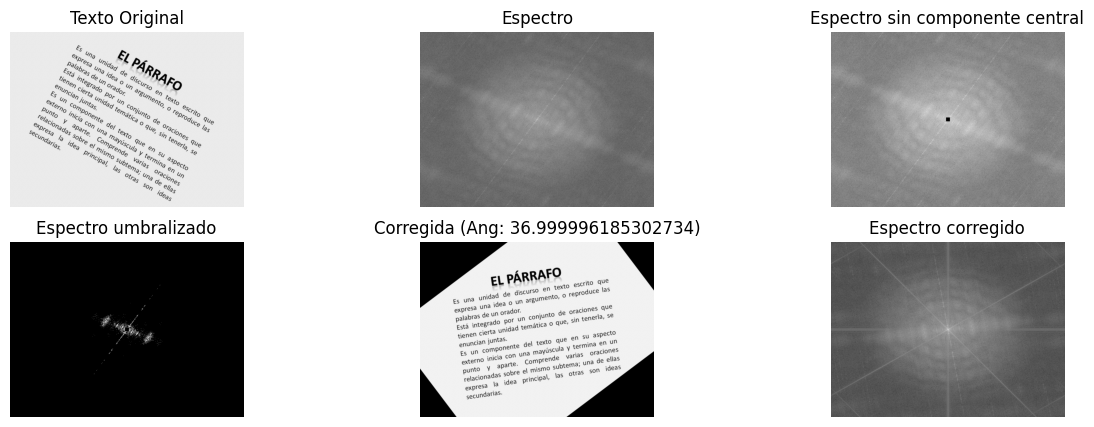

In [68]:
img = cv2.imread('imagenes/parrafo1.jpg', cv2.IMREAD_GRAYSCALE)

# PASO 1: Calcular la TDF de la imagen del texto
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
magnitud = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)
magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# PASO 2: Encontrar el ángulo de rotación
# borrar la componente del centro del espectro
espectro = magnitud.copy()
c_y, c_x = espectro.shape[0] // 2, espectro.shape[1] // 2   # centro
espectro[c_y-10:c_y+10, c_x-10:c_x+10] = 0  # cuadro negro

# umbralizar para aislar la línea brillante ortogonal
thresh = 160
lineasThresh = 75
_, espectro_thresh = cv2.threshold(espectro, thresh, 255, cv2.THRESH_BINARY)
lineas = cv2.HoughLines(espectro_thresh, 1, np.pi/180, lineasThresh)

# tomar linea con mas votos
rho, theta = lineas[0][0]
angulo = np.degrees(theta)

# PASO 3: Corregir la imagen
img_corregida = imutils.rotate(img, angle=angulo)

fig, ax = plt.subplots(2, 3, figsize=(15, 5))
ax[0][0].imshow(img, cmap='gray'); ax[0][0].set_title("Texto Original"); ax[0][0].axis('off')
ax[0][1].imshow(magnitud, cmap='gray'); ax[0][1].set_title("Espectro"); ax[0][1].axis('off')
ax[0][2].imshow(espectro, cmap='gray'); ax[0][2].set_title("Espectro sin componente central"); ax[0][2].axis('off')
ax[1][0].imshow(espectro_thresh, cmap='gray'); ax[1][0].set_title("Espectro umbralizado"); ax[1][0].axis('off')
ax[1][1].imshow(img_corregida, cmap='gray'); ax[1][1].set_title(f"Corregida (Ang: {angulo})"); ax[1][1].axis('off')

# espectro rotado
dft = cv2.dft(np.float32(img_corregida), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
magnitud = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1)
magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
ax[1][2].imshow(magnitud, cmap='gray'); ax[1][2].set_title(f"Espectro corregido"); ax[1][2].axis('off')

plt.show();